<a href="https://colab.research.google.com/github/jiminmini/mini/blob/ESAA_OB/11_24_%ED%95%84%EC%82%AC_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**[개념 정리]**

**[시계열 형태]**
- 불규칙 변동
- 추세 변동
- 순환 변동
- 계절 변동

**[AR 모델]**
- 자기회귀 모델
- 이전 관측 값이 이후 관측 값에 영향을 준다는 아이디어

**[ARIMA 모델]**
- 자기 회귀 누적 이동 평균 모델
- 과거 데이터의 선형 관계뿐만 아니라 추세까지 고려

**[순환 신경망]**
- 시간적으로 연속성이 있는 데이터 처리
- 기억을 갖고 있음
- 유형: 일대일, 일대다, 다대일

**[순환 신경망의 계층과 셀]**
- 계층은 셀을 래핑하여 동일한 셀을 여러 단계에 적용

- 셀: nn.RNNCell 등의 3가지 유형

**[RNN 실습]**
- 입력 데이터와 레이블 데이터에 대해서 문자 집합(voabulary) 생성

- fc는 완전 연결층(fully-connected layer)을 의미하며 출력층으로 사용됨

#**[코드 필사]**

In [1]:
!pip install statsmodels

/tmp/ipython-input-2655408267.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = read_csv('sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Sun, 02 Nov 2025   AIC                            411.302
Time:                        06:22:07   BIC                            420.634
Sample:                    01-01-1991   HQIC                           414.523
                         - 12-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8788      0.227     -3.876      0.000      -1.323      -0.434
ar.L2         -0.2787      0.232     -1.203      0.229      -0.733       0.176
ar.L3         -0.0076      0.270     -0.028      0.9

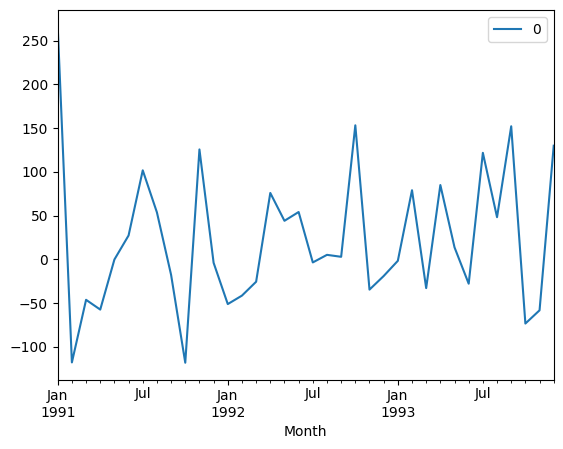

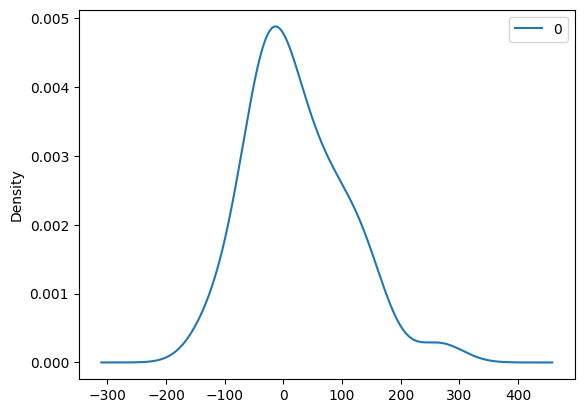

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [9]:
from pandas import read_csv, DataFrame
from datetime import datetime
from statsmodels.tsa.arima.model import ARIMA   # 최신 모듈로 변경
import matplotlib.pyplot as plt

def parser(x):
    return datetime.strptime('199' + x, '%Y-%m')

series = read_csv('sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)

model = ARIMA(series, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

residuals = DataFrame(model_fit.resid)

residuals.plot()
plt.show()

residuals.plot(kind='kde')
plt.show()

print(residuals.describe())


/usr/local/lib/python3.12/dist-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


predicted=352.855, expected=346.300
predicted=277.398, expected=329.700
predicted=368.754, expected=445.400
predicted=331.774, expected=325.900
predicted=372.070, expected=449.300
predicted=360.021, expected=411.300
predicted=454.526, expected=417.400
predicted=388.691, expected=545.500
predicted=437.632, expected=477.600
predicted=516.438, expected=687.000
predicted=520.916, expected=435.300
predicted=675.595, expected=587.300
predicted=505.201, expected=676.900
Test MSE: 9118.818


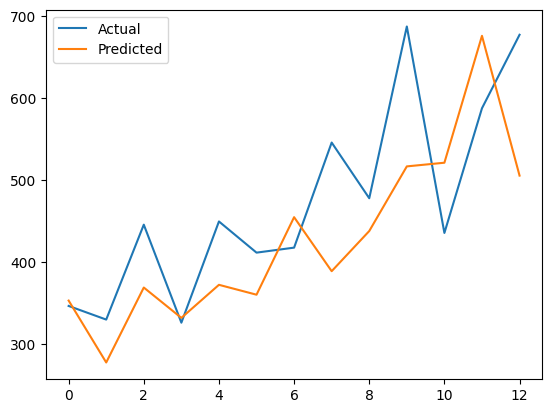

In [12]:
import numpy as np
from pandas import read_csv
from datetime import datetime
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def parser(x):
    return datetime.strptime('199' + x, '%Y-%m')

# 날짜 처리: read_csv 후 to_datetime 적용 방식 사용
series = read_csv('sales.csv', header=0)
series.iloc[:,0] = '199' + series.iloc[:,0]   # '93-01' → '1993-01'
series.iloc[:,0] = pd.to_datetime(series.iloc[:,0], format='%Y-%m')
series.set_index(series.columns[0], inplace=True)

X = series.values.flatten()
X = np.nan_to_num(X)

size = int(len(X) * 0.66)
train, test = X[:size], X[size:]
history = list(train)
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]  # numpy array → scalar
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)

    print(f'predicted={float(yhat):.3f}, expected={float(obs):.3f}')

error = mean_squared_error(test, predictions)
print(f'Test MSE: {error:.3f}')

plt.plot(test, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [14]:
input_str = 'apple'
label_str = 'pple!'
char_vocab = sorted(list(set(input_str+label_str)))
vocab_size = len(char_vocab)
print ('문자 집합의 크기 : {}'.format(vocab_size))

문자 집합의 크기 : 5


In [15]:
input_size = vocab_size # 입력의 크기는 문자 집합의 크기
hidden_size = 5
output_size = 5
learning_rate = 0.1


In [16]:
char_to_index = dict((c, i) for i, c in enumerate(char_vocab)) # 문자에 고유한 정수 인덱스 부여
print(char_to_index)


{'!': 0, 'a': 1, 'e': 2, 'l': 3, 'p': 4}


In [17]:
index_to_char={}
for key, value in char_to_index.items():
    index_to_char[value] = key
print(index_to_char)

{0: '!', 1: 'a', 2: 'e', 3: 'l', 4: 'p'}


In [18]:
x_data = [char_to_index[c] for c in input_str]
y_data = [char_to_index[c] for c in label_str]
print(x_data)
print(y_data)

[1, 4, 4, 3, 2]
[4, 4, 3, 2, 0]


In [19]:
# 배치 차원 추가
# 텐서 연산인 unsqueeze(0)를 통해 해결할 수도 있었음.
x_data = [x_data]
y_data = [y_data]
print(x_data)
print(y_data)

[[1, 4, 4, 3, 2]]
[[4, 4, 3, 2, 0]]


In [20]:
x_one_hot = [np.eye(vocab_size)[x] for x in x_data]
print(x_one_hot)


[array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.]])]


In [21]:
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

/tmp/ipython-input-2348034151.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.FloatTensor(x_one_hot)


In [22]:
print('훈련 데이터의 크기 : {}'.format(X.shape))
print('레이블의 크기 : {}'.format(Y.shape))

훈련 데이터의 크기 : torch.Size([1, 5, 5])
레이블의 크기 : torch.Size([1, 5])


In [23]:
class Net(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Net, self).__init__()
        self.rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True) # RNN 셀 구현
        self.fc = torch.nn.Linear(hidden_size, output_size, bias=True) # 출력층 구현

    def forward(self, x): # 구현한 RNN 셀과 출력층을 연결
        x, _status = self.rnn(x)
        x = self.fc(x)
        return x

In [24]:
net = Net(input_size, hidden_size, output_size)

In [25]:
outputs = net(X)
print(outputs.shape) # 3차원 텐서

torch.Size([1, 5, 5])


In [26]:
print(outputs.view(-1, input_size).shape) # 2차원 텐서로 변환

torch.Size([5, 5])


In [27]:
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([1, 5])
torch.Size([5])


In [28]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

In [29]:
for i in range(100):
    optimizer.zero_grad()
    outputs = net(X)
    loss = criterion(outputs.view(-1, input_size), Y.view(-1)) # view를 하는 이유는 Batch 차원 제거를 위해
    loss.backward() # 기울기 계산
    optimizer.step() # 아까 optimizer 선언 시 넣어둔 파라미터 업데이트

    # 아래 세 줄은 모델이 실제 어떻게 예측했는지를 확인하기 위한 코드.
    result = outputs.data.numpy().argmax(axis=2) # 최종 예측값인 각 time-step 별 5차원 벡터에 대해서 가장 높은 값의 인덱스를 선택
    result_str = ''.join([index_to_char[c] for c in np.squeeze(result)])
    print(i, "loss: ", loss.item(), "prediction: ", result, "true Y: ", y_data, "prediction str: ", result_str)


0 loss:  1.6236388683319092 prediction:  [[3 0 0 3 3]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  l!!ll
1 loss:  1.2942230701446533 prediction:  [[4 4 4 2 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppep
2 loss:  1.1201534271240234 prediction:  [[4 4 4 2 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppep
3 loss:  0.9885572195053101 prediction:  [[4 4 4 2 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppep
4 loss:  0.8601514101028442 prediction:  [[4 4 4 2 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppep
5 loss:  0.7308070659637451 prediction:  [[4 4 3 2 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pplep
6 loss:  0.6067289113998413 prediction:  [[4 4 3 2 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pplep
7 loss:  0.5000383257865906 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
8 loss:  0.42495617270469666 prediction:  [[4 0 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  p!le!
9 loss:  0.3602392077445984 prediction:  [[4 0 3 2 0]]

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim

In [31]:
sentence = ("if you want to build a ship, don't drum up people together to "
            "collect wood and don't assign them tasks and work, but rather "
            "teach them to long for the endless immensity of the sea.")


In [32]:
char_set = list(set(sentence)) # 중복을 제거한 문자 집합 생성
char_dic = {c: i for i, c in enumerate(char_set)} # 각 문자에 정수 인코딩

In [33]:
print(char_dic) # 공백도 여기서는 하나의 원소

{'i': 0, 'b': 1, 't': 2, 'a': 3, 'l': 4, 'c': 5, 'h': 6, 'f': 7, 'p': 8, 'y': 9, 'm': 10, "'": 11, 'w': 12, 'u': 13, 'g': 14, ' ': 15, ',': 16, 'e': 17, 'n': 18, 's': 19, 'o': 20, 'k': 21, 'r': 22, '.': 23, 'd': 24}


In [34]:
dic_size = len(char_dic)
print('문자 집합의 크기 : {}'.format(dic_size))

문자 집합의 크기 : 25


In [35]:
# 하이퍼파라미터 설정
hidden_size = dic_size
sequence_length = 10  # 임의 숫자 지정
learning_rate = 0.1

In [36]:
# 데이터 구성
x_data = []
y_data = []

for i in range(0, len(sentence) - sequence_length):
    x_str = sentence[i:i + sequence_length]
    y_str = sentence[i + 1: i + sequence_length + 1]
    print(i, x_str, '->', y_str)

    x_data.append([char_dic[c] for c in x_str])  # x str to index
    y_data.append([char_dic[c] for c in y_str])  # y str to index

0 if you wan -> f you want
1 f you want ->  you want 
2  you want  -> you want t
3 you want t -> ou want to
4 ou want to -> u want to 
5 u want to  ->  want to b
6  want to b -> want to bu
7 want to bu -> ant to bui
8 ant to bui -> nt to buil
9 nt to buil -> t to build
10 t to build ->  to build 
11  to build  -> to build a
12 to build a -> o build a 
13 o build a  ->  build a s
14  build a s -> build a sh
15 build a sh -> uild a shi
16 uild a shi -> ild a ship
17 ild a ship -> ld a ship,
18 ld a ship, -> d a ship, 
19 d a ship,  ->  a ship, d
20  a ship, d -> a ship, do
21 a ship, do ->  ship, don
22  ship, don -> ship, don'
23 ship, don' -> hip, don't
24 hip, don't -> ip, don't 
25 ip, don't  -> p, don't d
26 p, don't d -> , don't dr
27 , don't dr ->  don't dru
28  don't dru -> don't drum
29 don't drum -> on't drum 
30 on't drum  -> n't drum u
31 n't drum u -> 't drum up
32 't drum up -> t drum up 
33 t drum up  ->  drum up p
34  drum up p -> drum up pe
35 drum up pe -> rum up peo
36

In [37]:
print(x_data[0])
print(y_data[0])

[0, 7, 15, 9, 20, 13, 15, 12, 3, 18]
[7, 15, 9, 20, 13, 15, 12, 3, 18, 2]


In [38]:
x_one_hot = [np.eye(dic_size)[x] for x in x_data] # x 데이터는 원-핫 인코딩
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

In [39]:
print('훈련 데이터의 크기 : {}'.format(X.shape))
print('레이블의 크기 : {}'.format(Y.shape))

훈련 데이터의 크기 : torch.Size([170, 10, 25])
레이블의 크기 : torch.Size([170, 10])


In [40]:
print(X[0])

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,

In [41]:
print(Y[0])

tensor([ 7, 15,  9, 20, 13, 15, 12,  3, 18,  2])


In [42]:
class Net(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, layers): # 현재 hidden_size는 dic_size와 같음.
        super(Net, self).__init__()
        self.rnn = torch.nn.RNN(input_dim, hidden_dim, num_layers=layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim, hidden_dim, bias=True)

    def forward(self, x):
        x, _status = self.rnn(x)
        x = self.fc(x)
        return x

In [43]:
net = Net(dic_size, hidden_size, 2) # 이번에는 층을 두 개 쌓습니다.

In [44]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

In [45]:
outputs = net(X)
print(outputs.shape) # 3차원 텐서

torch.Size([170, 10, 25])


In [46]:
print(outputs.view(-1, dic_size).shape) # 2차원 텐서로 변환.

torch.Size([1700, 25])


In [47]:
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([170, 10])
torch.Size([1700])


In [48]:
for i in range(100):
    optimizer.zero_grad()
    outputs = net(X) # (170, 10, 25) 크기를 가진 텐서를 매 에포크마다 모델의 입력으로 사용
    loss = criterion(outputs.view(-1, dic_size), Y.view(-1))
    loss.backward()
    optimizer.step()

    # results의 텐서 크기는 (170, 10)
    results = outputs.argmax(dim=2)
    predict_str = ""
    for j, result in enumerate(results):
        if j == 0: # 처음에는 예측 결과를 전부 가져오지만
            predict_str += ''.join([char_set[t] for t in result])
        else: # 그 다음에는 마지막 글자만 반복 추가
            predict_str += char_set[result[-1]]

    print(predict_str)

fuwwwwwwffwwwwwwwwwwwwwwwfwwwwwfwuwwwwfwwwwwwwwwwwwwfwwwfwwwwwwuwwwwuwwwwwwwfwwwufwhwufwuwwwwwffwwffwwwuuwwwwwwwwwwwwwufwfwwwwuwuwwwffwwwwwwfwwwwwwwwfwwwwlufwwufuwwwuwwwuwwwwfwwuy
oooccooocooooooooococooooooccooooooocoooooooccccccooooooooooooooccccoooocoooooooooooooooooooooooooooooooooooocoooooooocoooooooooooocooooooccooooocoocoooooccooooooooooooooooocooooo
oottootttooootooooootototoootoootooooottootooooootoottoooootottot ootoooototooootototooototooot tottootstotooototooottootoootooootoootooooootoootototototoootototototdtootototototo
  t  t t   t  t tt tt w  t  t w   t w  t  t wt w   t  t  t  w  w  wt w  w  t t  w   t wt  w  t  t tt w  w   w   t tt  t      wt t  t  t  t wt w  t  t tt  t   w t         tt w    t
  t  et    e       et t d e t a   e e  t  t   eeet   dee  t  t  e ee e    t   d e t e   f e  e  t  td f   d e t t t   e eeet   tet e     t et t   t e d e e s f     df    et e   e 
t d d.wn shdhsdit.dnd t d.i dhw.i dhs.ndisw s..int  ti.ts.i  di dhst  t .w.nd dnd.w dud.wnti.stnt  t